# Customer Segmentation using K-Means Clustering
In this project, we will perform customer segmentation on the Mall Customers dataset using K-Means Clustering.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')
from sklearn.metrics import silhouette_score, davies_bouldin_score
# Hides unnecessary warnings in output  

## Load the Dataset

In [2]:
df = pd.read_csv('Mall_Customers.csv')
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## Select Features for Clustering
We will use 'Annual Income (k$)' and 'Spending Score (1-100)' for clustering.

In [3]:
X = df.iloc[:, [3, 4]].values

## Finding the optimal number of clusters using the Elbow Method

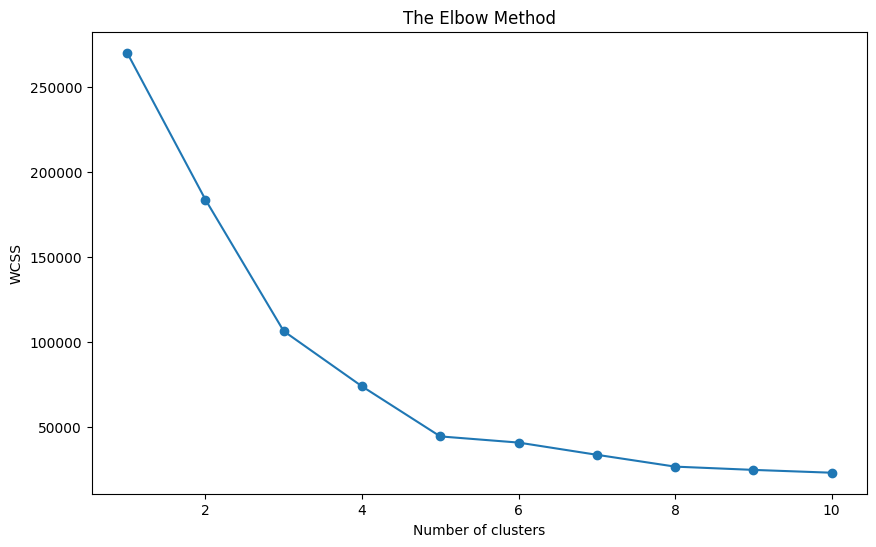

In [4]:
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10,6)) #Sets graph size
plt.plot(range(1, 11), wcss, marker='o')
        # X-axis → number of clusters (1 to 10)
        # Y-axis → WCSS values
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

## Training the K-Means model on the dataset
From the elbow plot, we can see that the optimal number of clusters is 5.

In [5]:
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42)
y_kmeans = kmeans.fit_predict(X)

## Visualizing the Clusters

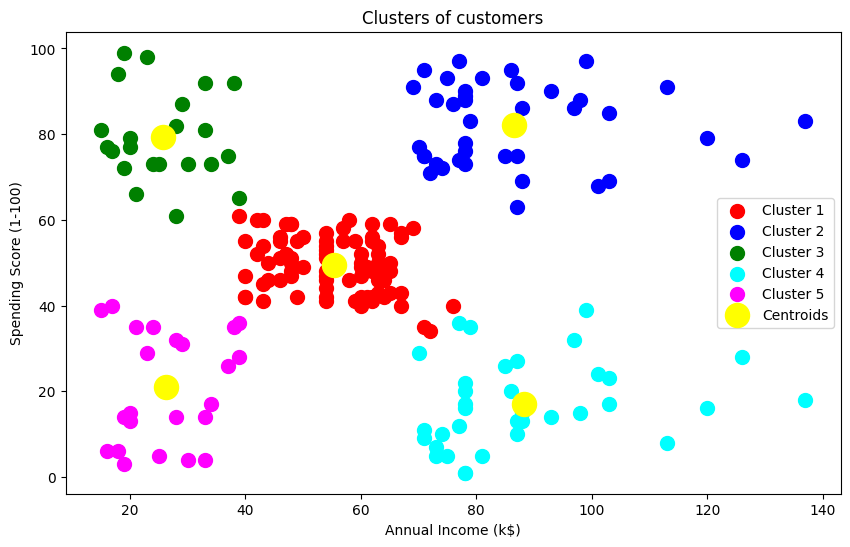

In [6]:
plt.figure(figsize=(10,6))
plt.scatter(X[y_kmeans == 0, 0], X[y_kmeans == 0, 1], s=100, c='red', label='Cluster 1')
plt.scatter(X[y_kmeans == 1, 0], X[y_kmeans == 1, 1], s=100, c='blue', label='Cluster 2')
plt.scatter(X[y_kmeans == 2, 0], X[y_kmeans == 2, 1], s=100, c='green', label='Cluster 3')
plt.scatter(X[y_kmeans == 3, 0], X[y_kmeans == 3, 1], s=100, c='cyan', label='Cluster 4')
plt.scatter(X[y_kmeans == 4, 0], X[y_kmeans == 4, 1], s=100, c='magenta', label='Cluster 5')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=300, c='yellow', label='Centroids')
plt.title('Clusters of customers')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()

In [7]:
print("Silhouette Score:", silhouette_score(X, y_kmeans))
print("Davies-Bouldin Score:", davies_bouldin_score(X, y_kmeans))
print("WCSS:", kmeans.inertia_)

Silhouette Score: 0.553931997444648
Davies-Bouldin Score: 0.5725628995597082
WCSS: 44448.45544793371
